In [1]:
import xarray as xr
import matplotlib.pyplot as plt

In [3]:
oce_new = xr.open_dataset("../Baltic_OM4_05_rainice_separate/19000101.ocean_daily.nc")
ice_new = xr.open_dataset("../Baltic_OM4_05_rainice_separate/19000101.ice_daily.nc")
sna_new = xr.open_dataset("../Baltic_OM4_05_rainice_separate/19000101.ocean_daily_snap.nc")
oce_old = xr.open_dataset("../Baltic_OM4_05_rainice_combined/19000101.ocean_daily.nc")
ice_old = xr.open_dataset("../Baltic_OM4_05_rainice_combined/19000101.ice_daily.nc")
sna_old = xr.open_dataset("../Baltic_OM4_05_rainice_combined/19000101.ocean_daily_snap.nc")

og = xr.open_dataset("../Baltic_OM4_05_rainice_combined/ocean_geometry.nc")

ti = 8
ti_snap = ti - 1

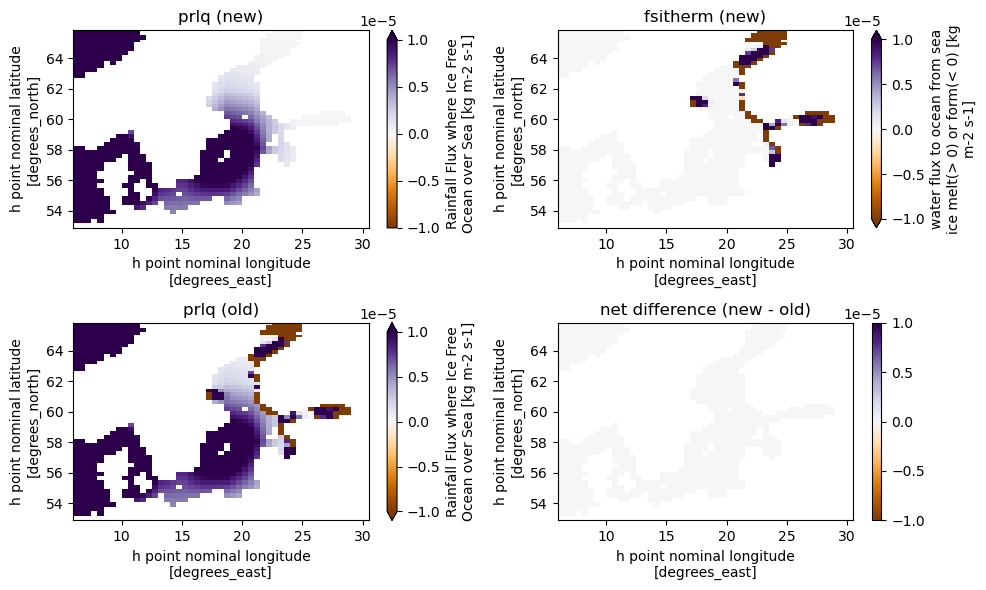

In [6]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2,2, figsize=(10, 6))
pc = oce_new.prlq.isel(time=ti).plot(ax=axes[0][0], cmap="PuOr", vmin=-1e-5, vmax=1e-5)
axes[0,0].set_title("prlq (new)")

pc = oce_new.fsitherm.isel(time=ti).plot(ax=axes[0][1], cmap="PuOr", vmin=-1e-5, vmax=1e-5)
axes[0,1].set_title("fsitherm (new)")

pc = oce_old.prlq.isel(time=ti).plot(ax=axes[1][0], cmap="PuOr", vmin=-1e-5, vmax=1e-5)
axes[1,0].set_title("prlq (old)")

pc = ((oce_new.fsitherm + oce_new.prlq).isel(time=ti) - oce_old.prlq.isel(time=ti).values).plot(ax=axes[1,1], cmap="PuOr", vmin=-1e-5, vmax=1e-5)
axes[1,1].set_title("net difference (new - old)")
plt.tight_layout()

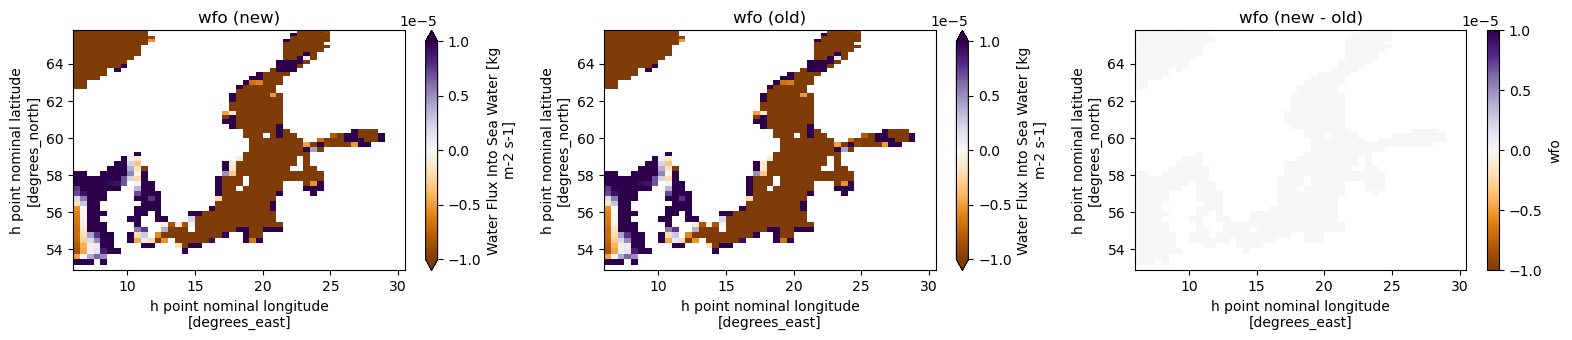

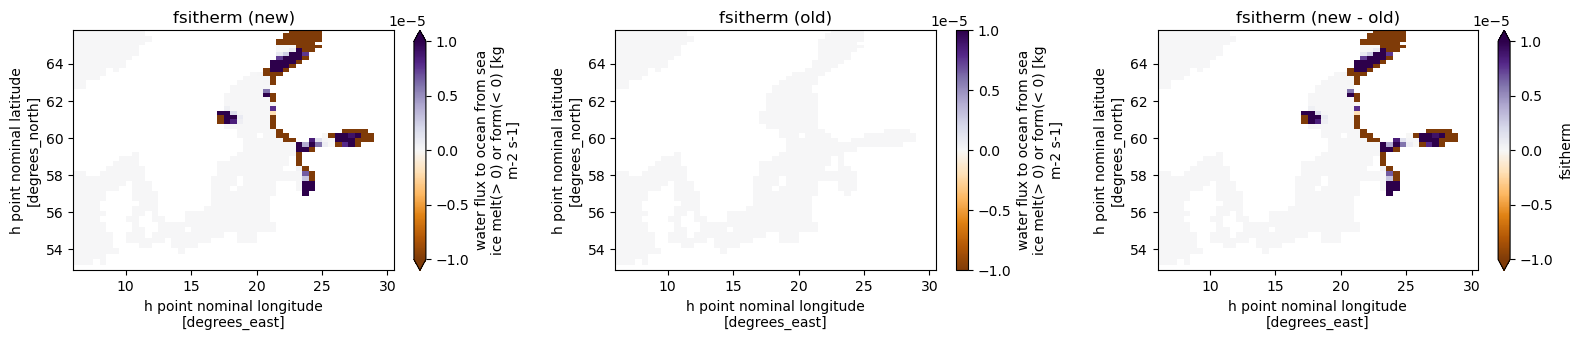

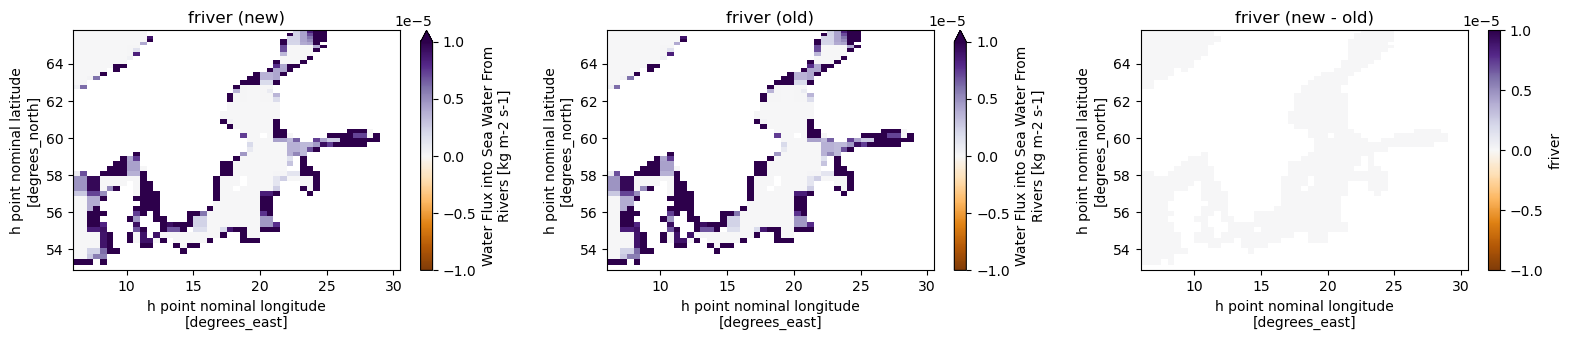

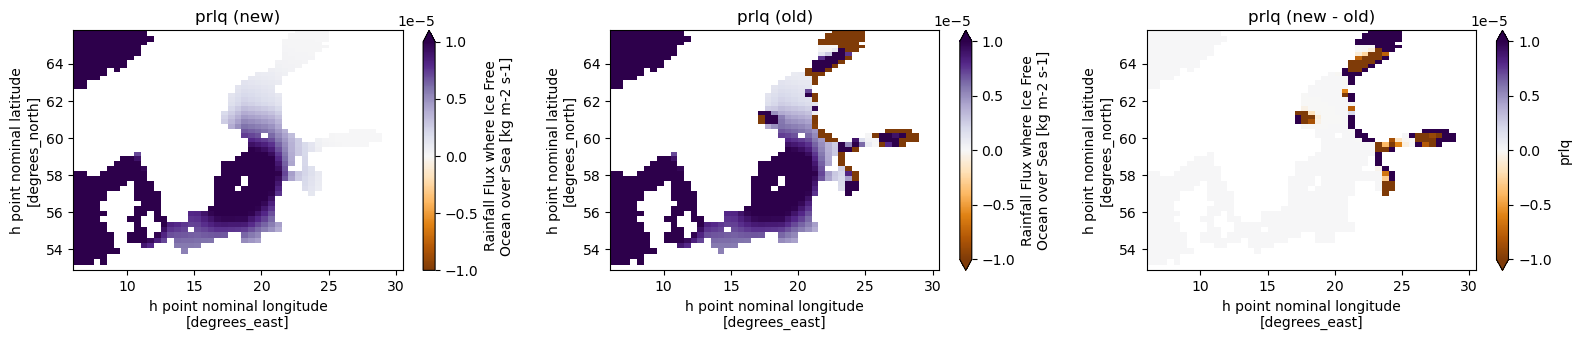

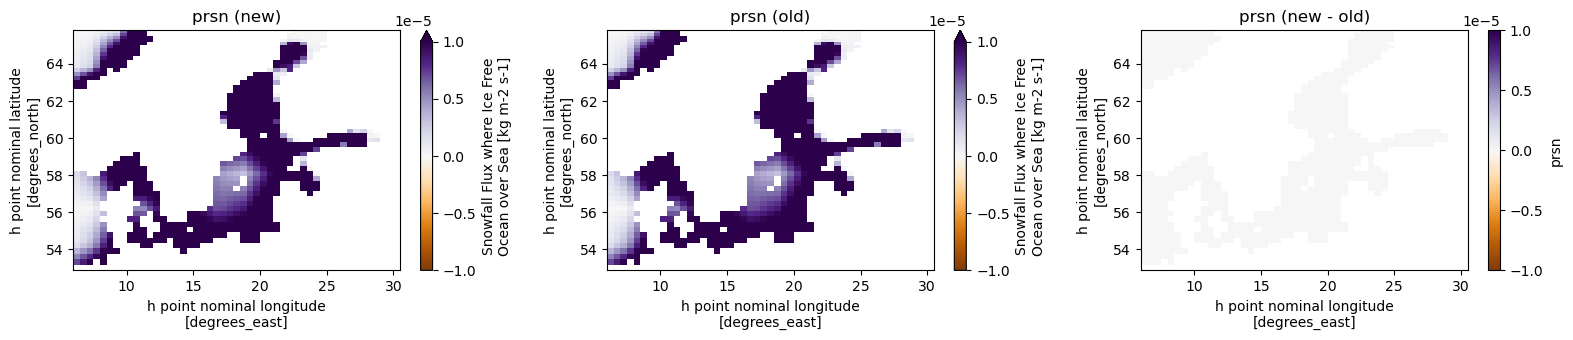

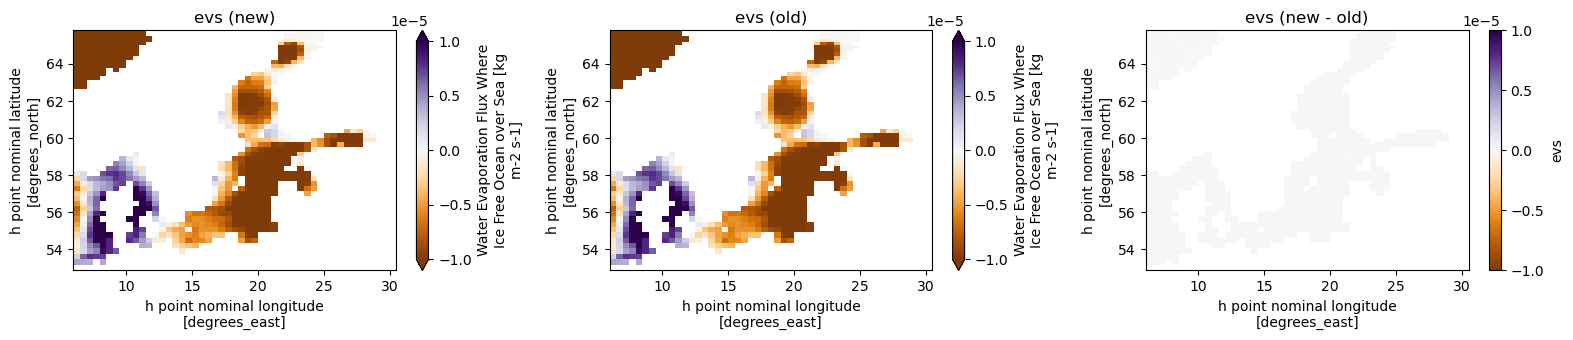

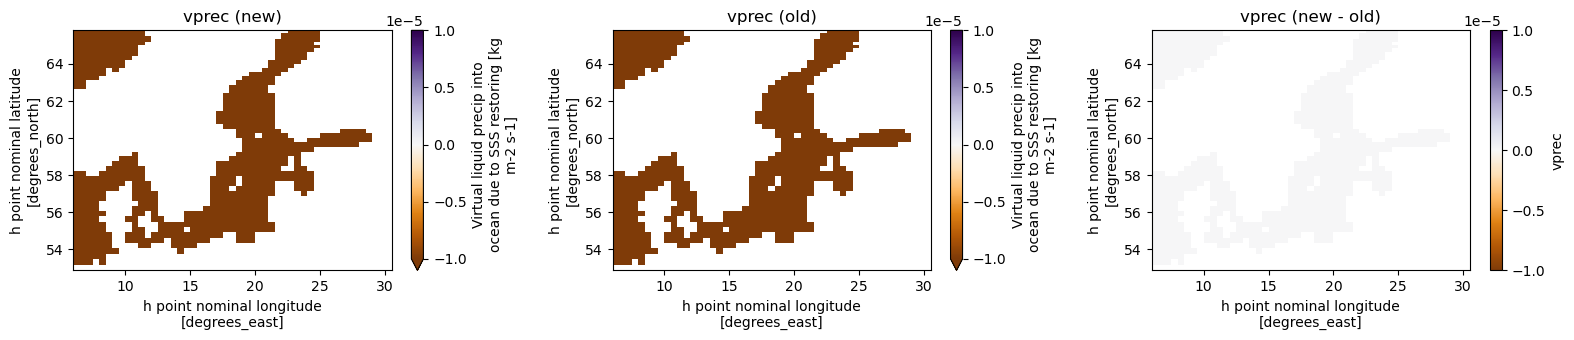

In [8]:
for v in ["wfo", "fsitherm", "friver", "prlq", "prsn", "evs", "vprec"]:
    plt.figure(figsize=(16,3.5))
    plt.subplot(1,3,1)
    oce_new[v].isel(time=ti).plot(cmap="PuOr", vmin=-1e-5, vmax=1e-5)
    plt.title(f"{v} (new)")
    plt.subplot(1,3,2)
    oce_old[v].isel(time=ti).plot(cmap="PuOr", vmin=-1e-5, vmax=1e-5)
    plt.title(f"{v} (old)")
    plt.subplot(1,3,3)
    (oce_new[v].isel(time=ti) - oce_old[v].isel(time=ti).values).plot(cmap="PuOr", vmin=-1e-5, vmax=1e-5)
    plt.title(f"{v} (new - old)")
    plt.tight_layout()

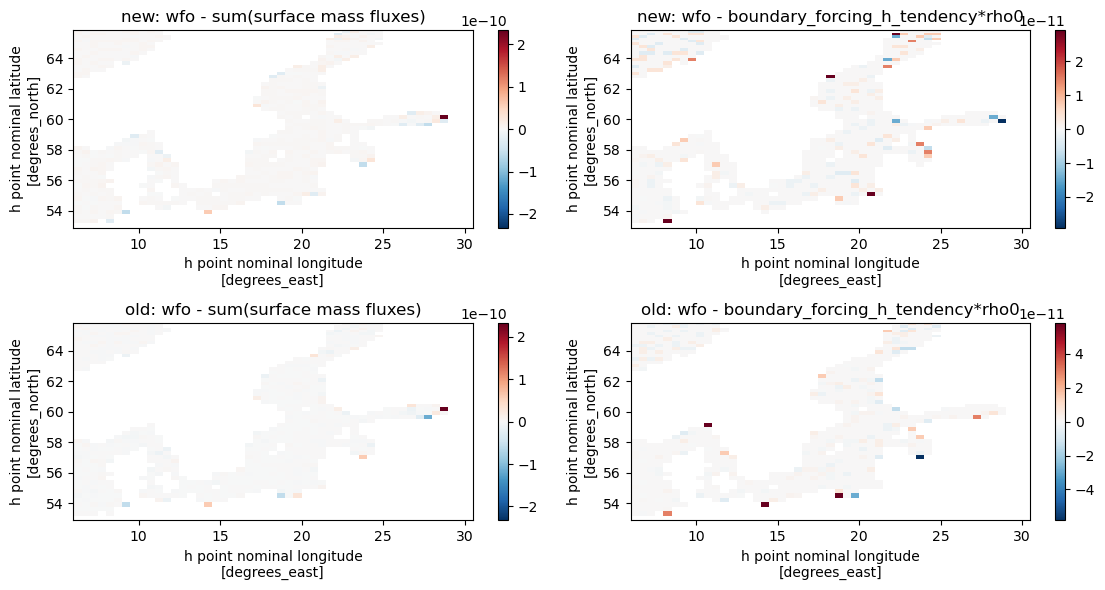

In [9]:
fig, axes = plt.subplots(2,2,figsize=(11.5, 6))
pc = (oce_new.wfo - (oce_new.fsitherm + oce_new.ficeberg + oce_new.friver + oce_new.prlq + oce_new.prsn + oce_new.evs + oce_new.vprec)).isel(time=ti).plot(ax=axes[0,0])
axes[0,0].set_title("new: wfo - sum(surface mass fluxes)")

pc = ((oce_new.boundary_forcing_h_tendency*1035).sum("zl") - oce_new.wfo).isel(time=ti).plot(ax=axes[0,1])
axes[0,1].set_title("new: wfo - boundary_forcing_h_tendency*rho0");

pc = (oce_old.wfo - (oce_old.fsitherm + oce_old.ficeberg + oce_old.friver + oce_old.prlq + oce_old.prsn + oce_old.evs + oce_old.vprec)).isel(time=ti).plot(ax=axes[1,0])
axes[1,0].set_title("old: wfo - sum(surface mass fluxes)")

pc = ((oce_old.boundary_forcing_h_tendency*1035).sum("zl") - oce_old.wfo).isel(time=ti).plot(ax=axes[1,1])
axes[1,1].set_title("old: wfo - boundary_forcing_h_tendency*rho0");
plt.tight_layout()